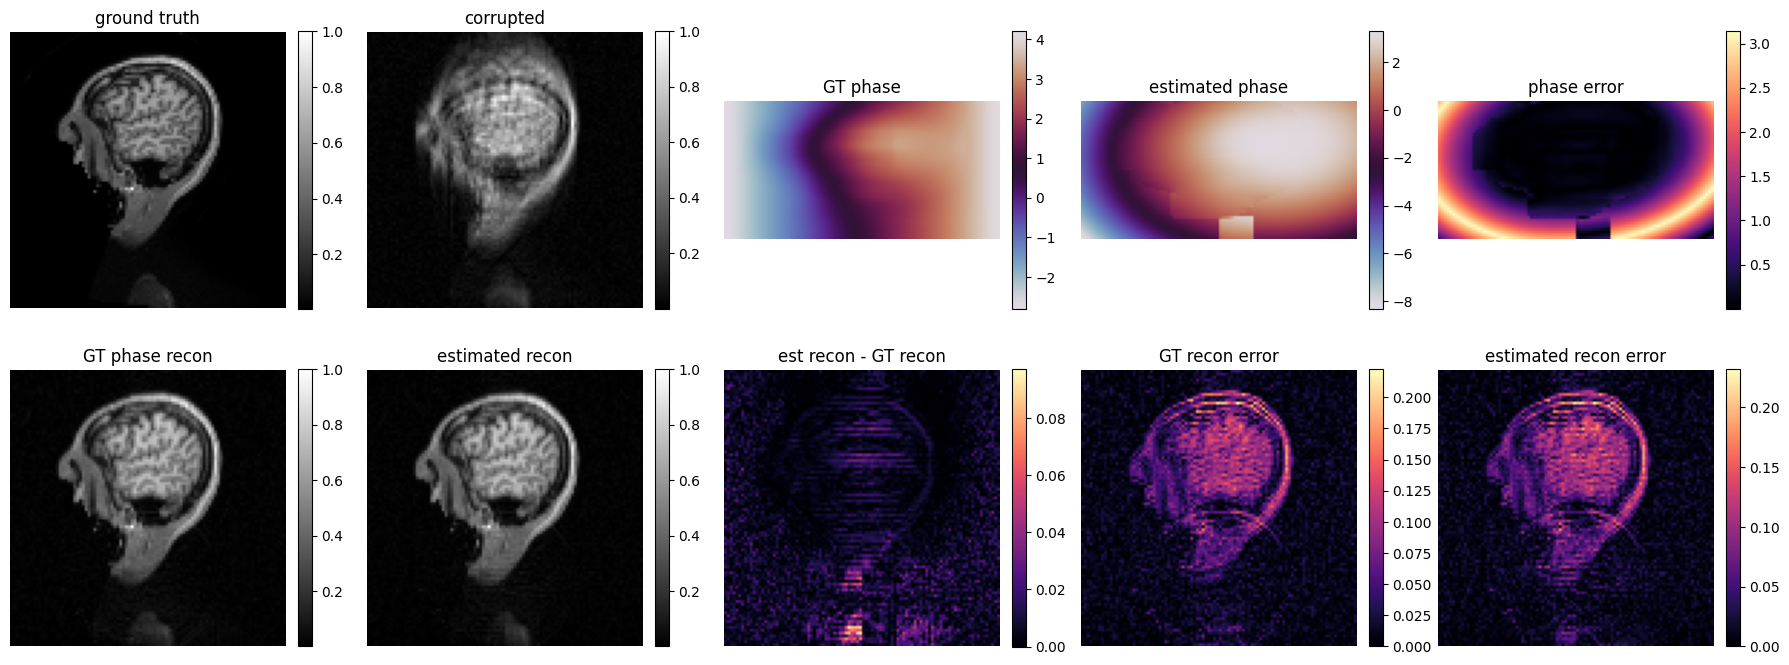

In [1]:
import sys
from pathlib import Path

import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt

ROOT = Path("/home/data1/musong/workspace/python/spen_recons")
sys.path.insert(0, str(ROOT / "spenpy"))

from spenpy.sim import SpenSim
from spenpy.core import calcInvA
from spenpy.recon.phase import even_odd_phase_fit_torch
from spenpy.utils.coil_combine import coil_combine


def pil_to_float_tensor(path: Path) -> torch.Tensor:
    image = Image.open(path).convert("L")
    data = torch.frombuffer(bytearray(image.tobytes()), dtype=torch.uint8).to(torch.float32)
    return data.reshape(image.height, image.width) / 255.0


img_path = ROOT / "spenpy/spenpy/data/brain.png"
img = pil_to_float_tensor(img_path)
gt = F.interpolate(img[None, None], size=(96, 96), mode="bilinear", align_corners=False)[0, 0]
noise_level = 0.08

sim_config = {
    "scanner": {"L": [3.5, 3.5], "acq_point": [96, 96], "nseg": 1},
    "randomization": {"seed": 0},
    "scanner_raw": {"num_coils": 4, "coil_combine": "adaptive"},
    "artifacts": {
        "even_odd": {
            "enabled": True,
            "constant_range_rad": [0.7, 0.7],
            "linear_range_rad_per_cm": [2.0, 2.0],
            "object_phase_scale_range_rad": [2.0, 2.0],
        },
        "noise": {"complex_std": [noise_level, noise_level]},
    },
}

sim = SpenSim(config=sim_config)
raw = sim.sim_scanner_raw(gt, num_coils=4)
corrupted = raw.raw_rofft_coils.permute(0, 3, 1, 2).contiguous()
corrupted_combined = raw.raw_rofft
phase_gt = raw.phase_map_true

InvA = raw.inv_a


def combine_bcro(x):
    return torch.stack([coil_combine(x[i].permute(1, 2, 0).contiguous()) for i in range(x.shape[0])])


corrected_gt = corrupted.clone()
corrected_gt[:, :, 1::2, :] *= torch.exp(-1j * phase_gt[:, None])
recon_gt = combine_bcro(torch.matmul(InvA, corrected_gt))

half_pe = corrupted.shape[2] // 2
odd_inv, _ = calcInvA(sim.alfa, sim.L[0], half_pe, 0, -sim.a_sign, 0, sim.gauss_relative_width)
even_inv, _ = calcInvA(sim.alfa, sim.L[0], half_pe, 0, -sim.a_sign, 0.5, sim.gauss_relative_width)

odd_sr = torch.matmul(odd_inv.to(torch.complex64), corrupted[:, :, 0::2, :])
even_sr = torch.matmul(even_inv.to(torch.complex64), corrupted[:, :, 1::2, :])

fit = even_odd_phase_fit_torch(
    odd_sr[0].permute(1, 2, 0).contiguous(),
    even_sr[0].permute(1, 2, 0).contiguous(),
)
phase_est = fit.smooth_phase.float()[None]

corrected_est = corrupted.clone()
corrected_est[:, :, 1::2, :] *= torch.exp(-1j * phase_est[:, None])
recon_est = combine_bcro(torch.matmul(InvA, corrected_est))


def norm_img(x):
    x = x.abs() if torch.is_complex(x) else x
    return x / x.max().clamp_min(1e-8)


gt_img = norm_img(gt)
corrupted_img = norm_img(corrupted_combined[0])
recon_gt_img = norm_img(recon_gt[0])
recon_est_img = norm_img(recon_est[0])

phase_err = torch.angle(torch.exp(1j * (phase_est - phase_gt))).abs()[0]
recon_diff = (recon_est_img - recon_gt_img).abs()
gt_phase_err = (recon_gt_img - gt_img).abs()
est_phase_err = (recon_est_img - gt_img).abs()


def show(a, data, title, cmap):
    data = data.detach().cpu() if isinstance(data, torch.Tensor) else data
    im = a.imshow(data, cmap=cmap)
    a.set_title(title)
    a.axis("off")
    plt.colorbar(im, ax=a, fraction=0.046, pad=0.04)


fig, ax = plt.subplots(2, 5, figsize=(18, 7))

show(ax[0, 0], gt_img, "ground truth", "gray")
show(ax[0, 1], corrupted_img, "corrupted", "gray")
show(ax[0, 2], phase_gt[0], "GT phase", "twilight")
show(ax[0, 3], phase_est[0], "estimated phase", "twilight")
show(ax[0, 4], phase_err, "phase error", "magma")

show(ax[1, 0], recon_gt_img, "GT phase recon", "gray")
show(ax[1, 1], recon_est_img, "estimated recon", "gray")
show(ax[1, 2], recon_diff, "est recon - GT recon", "magma")
show(ax[1, 3], gt_phase_err, "GT recon error", "magma")
show(ax[1, 4], est_phase_err, "estimated recon error", "magma")

plt.tight_layout()


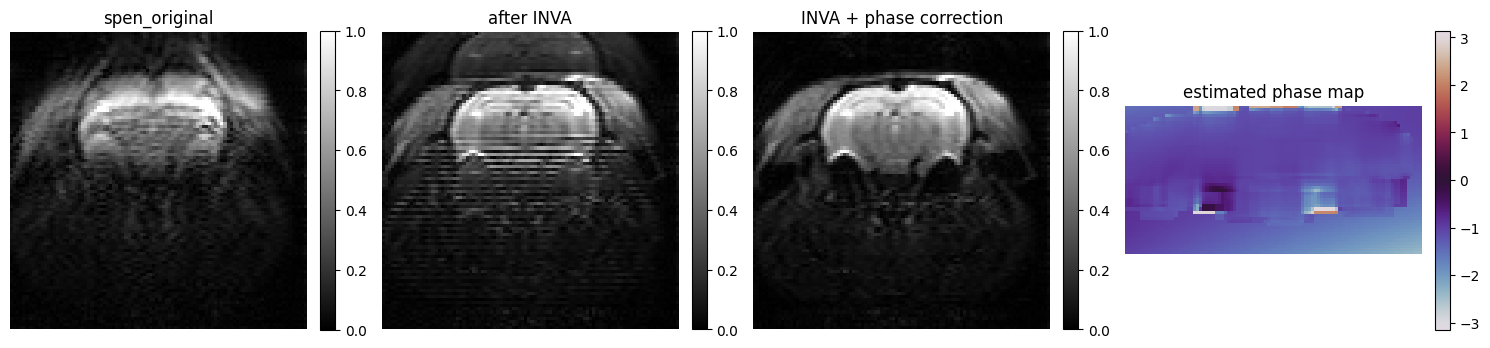

In [2]:
import sys
from pathlib import Path

import torch
import scipy.io
import matplotlib.pyplot as plt

ROOT = Path("/home/data1/musong/workspace/python/spen_recons")
sys.path.insert(0, str(ROOT / "spenpy"))

from spenpy.core import calcInvA
from spenpy.recon.phase import even_odd_phase_fit_torch
from spenpy.utils.coil_combine import coil_combine
from spenpy.utils.tensor import mult_mat_tensor

mat_path = ROOT / "data/mat/20231011_lxj_SPEN_data_231011_3_1_3/slice_19.mat"
mat = scipy.io.loadmat(mat_path, squeeze_me=True, struct_as_record=False)

spen_original = torch.as_tensor(mat["spen_original"])
rofft_np = mat["spen_original_signal_rofft"]
if rofft_np.ndim == 3:
    rofft_np = rofft_np[:, :, None, :]
rofft = torch.as_tensor(rofft_np, dtype=torch.complex64)

params = mat["calc_inva_params"]


def build_inva(args):
    args = torch.as_tensor(args, dtype=torch.float64).flatten()
    inv_a, _ = calcInvA(
        args[0],
        args[1],
        int(args[2].item()),
        args[3],
        int(args[4].item()),
        args[5],
        args[6],
    )
    return inv_a.to(torch.complex64)


inv_a = build_inva(params.full_args)
odd_inv = build_inva(params.odd_args)
even_inv = build_inva(params.even_args)


def recon_from_rofft(signal):
    sr = mult_mat_tensor(inv_a, signal)
    return coil_combine(sr[:, :, 0, :].unsqueeze(2)).squeeze()


def orient_for_display(image):
    return torch.flip(image, dims=(0, 1))


def display_abs(image, percentile=99.5):
    image = torch.abs(image).to(torch.float32)
    positive = image[image > 0]
    if positive.numel() == 0:
        scale = torch.tensor(1.0, dtype=image.dtype, device=image.device)
    else:
        scale = torch.quantile(positive, percentile / 100.0).clamp_min(1e-8)
    return torch.clamp(image / scale, 0.0, 1.0)


recon_inva = recon_from_rofft(rofft)

odd_sr = mult_mat_tensor(odd_inv, rofft[0::2, :, :, :])
even_sr = mult_mat_tensor(even_inv, rofft[1::2, :, :, :])

fit = even_odd_phase_fit_torch(
    odd_sr[:, :, 0, :].contiguous(),
    even_sr[:, :, 0, :].contiguous(),
)
phase_map = fit.smooth_phase.float()

corrected_rofft = rofft.clone()
corrected_rofft[1::2, :, :, :] *= torch.exp(-1j * phase_map[:, :, None, None])
recon_inva_phase = recon_from_rofft(corrected_rofft)

spen_original_img = display_abs(spen_original)
recon_inva_img = display_abs(orient_for_display(recon_inva))
recon_inva_phase_img = display_abs(orient_for_display(recon_inva_phase))
phase_img = torch.angle(torch.exp(1j * orient_for_display(phase_map)))

fig, ax = plt.subplots(1, 4, figsize=(15, 4))
for axis, image, title, cmap, vmin, vmax in [
    (ax[0], spen_original_img, "spen_original", "gray", 0.0, 1.0),
    (ax[1], recon_inva_img, "after INVA", "gray", 0.0, 1.0),
    (ax[2], recon_inva_phase_img, "INVA + phase correction", "gray", 0.0, 1.0),
    (ax[3], phase_img, "estimated phase map", "twilight", -float(torch.pi), float(torch.pi)),
]:
    im = axis.imshow(image.detach().cpu(), cmap=cmap, vmin=vmin, vmax=vmax)
    axis.set_title(title)
    axis.axis("off")
    plt.colorbar(im, ax=axis, fraction=0.046, pad=0.04)
plt.tight_layout()
